## Importing Libraries

In [13]:
import numpy as np
import tensorflow as tf
print(np.__version__)
print(tf.__version__)

1.24.3
2.10.0


In [14]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

### Loading Model

In [15]:
model  = tf.keras.models.load_model('trained_model.keras')

In [16]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

### Visualizaing Single Image of Test set

In [17]:
!pip install opencv-python

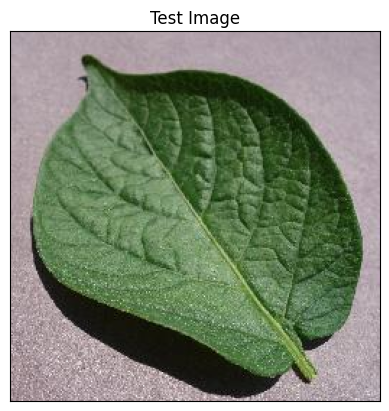

In [18]:
import cv2
image_path = "test/test/PotatoHealthy1.JPG"
#Reading Image
img = cv2.imread(image_path)
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #Convert BGR image to RGB

#Displaying Image
plt.imshow(img)
plt.title("Test Image")
plt.xticks([])
plt.yticks([])
plt.show()

## Testing Model

In [19]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128, 128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #Convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [20]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 1s 661ms/step


(array([[3.1082077e-09, 1.2579275e-08, 2.4844562e-11, 2.1605135e-04,
         1.0928664e-09, 3.0523786e-08, 3.5748038e-05, 3.5356783e-12,
         3.7461774e-12, 1.2945654e-12, 8.9230023e-13, 1.0329485e-12,
         1.6726003e-12, 4.2091057e-12, 6.7070815e-12, 3.7395885e-08,
         6.7268180e-10, 3.7972195e-11, 9.6844303e-08, 2.6719152e-05,
         2.7115492e-09, 8.1194456e-05, 9.9963999e-01, 9.3190795e-11,
         1.5577444e-07, 1.1527038e-13, 1.2472624e-12, 1.1294167e-10,
         9.6167458e-12, 5.1770366e-10, 8.5232932e-09, 1.9516581e-10,
         5.2516547e-11, 8.0800332e-11, 8.9101926e-10, 9.1355818e-13,
         2.7002613e-13, 4.6707200e-12]], dtype=float32),
 (1, 38))

In [21]:
result_index = np.argmax(prediction)
result_index

22

In [22]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

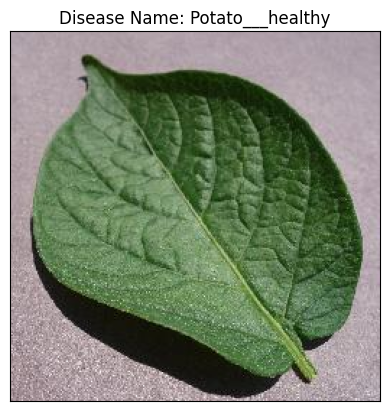

In [23]:
#Displaying Result of disease prediction
model_prediction = class_name[result_index]
plt.imshow(img)
plt.title(f"Disease Name: {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

In [24]:
model_prediction

'Potato___healthy'